In [2]:
!python --version

Python 3.12.9


In [3]:
!which python

/Users/niteshkr2209/Downloads/venv312/bin/python


In [4]:
# !pip install --upgrade --pre pykx

In [5]:
# import pykx as kx

In [6]:
# %%q
# til 10

In [7]:
# !pip install arviz pymc pytensor

In [8]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from pymc import GARCH11
from pytensor import shared
import pytensor
pytensor.config.mode = 'NUMBA'


In [11]:
# Download the dataset
m5_data = pd.read_csv("M5. goog_eur_10.csv")
# Convert date variable to date format
m5_data["Date2"] = pd.to_datetime(m5_data["Date"], format="%m/%d/%Y")
goog = m5_data.loc[:, ["Date2", "GOOGLE"]].set_index("Date2")
goog["GOOGLE_R"] = np.log(goog.GOOGLE).diff().dropna()

In [12]:
goog

,GOOGLE,GOOGLE_R
Date2,,
2016-01-04,741.840027,NaN
2016-01-05,742.580017,0.000997
2016-01-06,743.619995,0.001400
2016-01-07,726.390015,-0.023443
2016-01-08,714.469971,-0.016546
...,...,...
2021-12-23,2942.850098,0.001316
2021-12-27,2961.280029,0.006243
2021-12-28,2928.959961,-0.010974


In [13]:
# beysian estimation: assume that parameters like mean, median are unknown but fixed

In [ ]:
# # % --- IGNORE ---
# This is the main difference between
# frequentist statistics and Bayesian statistics. To run Bayesian statistics, a researcher has to either use experience or other techniques
# to assume a parameter's probability distribution before running the analysis. We call these probability distributions prior probability
# distributions or priors. We then combine the information from data to derive posterior probability distributions for parameters or
# posteriors.

# Bayesian Estimation on GARCH Model

In [18]:
alpha_mu = shared(np.array([0.000001, 0.000001], dtype=np.float64))
alpha_sigma = shared(np.array([[1000.0, 0.0], [0.0, 1000.0]], dtype=np.float64))

beta_mu = shared(np.array(0.000001, dtype=np.float64))
beta_sigma = shared(np.array(1000.0, dtype=np.float64))

In [19]:
# initial volatility
ivolatility = shared(np.array(0.000001, dtype=np.float64))
ivolatility_vol = shared(np.array(10.0, dtype=np.float64))

In [20]:
# construct MCMC model
mcmc0 = pm.Model()

with mcmc0:
    # create multivariate normal: p(α) ∝ φN2(α|µα,Σα) 1 {α ∈ R^2+}
    mvn = pm.MvNormal("mvNormal", mu=alpha_mu, cov=alpha_sigma, shape=2)
    # restrict the two coefficients to be greater than zero
    alp0 = pm.Deterministic("alpha0", pm.math.switch(mvn[0] > 0, mvn[0], -np.inf))
    alp1 = pm.Deterministic("alpha1", pm.math.switch(mvn[1] > 0, mvn[1], -np.inf))
    # create univariate truncated normal: p(β) ∝ φN1(β|µβ,Σβ) 1{β ∈ R+}
    nTruncated = pm.TruncatedNormal("beta", mu=beta_mu, sigma=beta_sigma, lower=0)
    volTruncated = pm.TruncatedNormal(
    "volatility", mu=ivolatility, sigma=ivolatility_vol, lower=0
    )
    # likelihood
    likelihood = GARCH11(
    "GARCH",
    omega=alp0,
    alpha_1=alp1,
    beta_1=nTruncated,
    initial_vol=volTruncated,
    observed=goog.GOOGLE_R.dropna() * 100,
    )

In [24]:
# !pip install numba

In [25]:
import numba


Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Slice: [mvNormal]
>Slice: [beta]
>Slice: [volatility]


Output()

Sampling 2 chains for 0 tune and 3_000 draw iterations (0 + 6_000 draws total) took 30 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


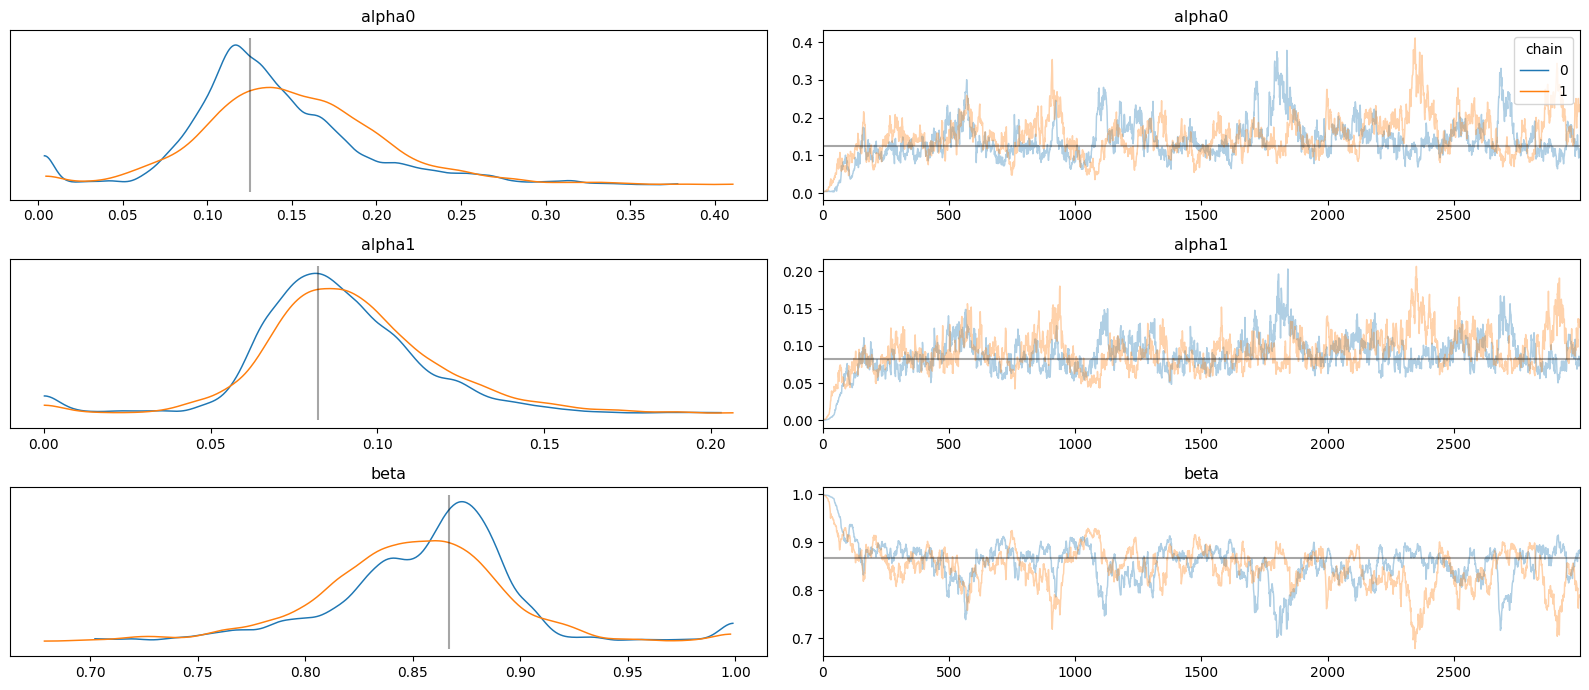

In [26]:
# Plot first round MCMC model posteriors
with mcmc0:
    step_mcmc0 = pm.Slice()
    trace_mcmc0 = pm.sample(
    3000,
    cores=2,
    step=step_mcmc0,
    tune=0, # tune=0 => no burn-in
    return_inferencedata=True,
    random_seed=12345,
    )
    az.plot_trace(
    trace_mcmc0,
    var_names=["alpha0", "alpha1", "beta"],
    # plot vertical lines at GARCH(1,1) MLE param results
    lines=[
    ("alpha0", {}, [0.124993]),
    ("alpha1", {}, [0.082160]),
    ("beta", {}, [0.867127]),
    ],
    compact=False,
    legend=True,
    figsize=(16, 7),
    )
    plt.tight_layout()
    plt.show()

In [27]:
az.summary(trace_mcmc0, round_to=7).loc[["alpha0", "alpha1", "beta"], :]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha0,0.145094,0.053294,0.059351,0.262754,0.007721,0.004627,47.599936,51.832998,1.068832
alpha1,0.089880,0.025170,0.048496,0.141094,0.003876,0.002370,47.796746,48.588985,1.066640
beta,0.852806,0.042358,0.757265,0.916286,0.006640,0.004178,44.814853,48.402712,1.074747


In [28]:
# Second Round MCMC Sampling Result: Parameter Trace Plots and Marginal Density Plots
# starting parameters = MLE(0.124993, 0.082160, 0.867127)
alpha_mu = shared(np.array([0.124993, 0.082160], dtype=np.float64))
alpha_sigma = shared(np.array([[1000.0, 0.0], [0.0, 1000.0]], dtype=np.float64))
beta_mu = shared(np.array(0.867127, dtype=np.float64))
beta_sigma = shared(np.array(1000.0, dtype=np.float64))
# initial volatility
ivolatility = shared(
np.array(1.63865, dtype=np.float64)
) # np.std(goog["GOOGLE_R"].dropna()*100)
ivolatility_vol = shared(np.array(10.0, dtype=np.float64))
# construct MCMC model
mcmc = pm.Model()
with mcmc:
    # create a multivariate normal: p(α) ∝ φN2(α|µα,Σα) 1 {α ∈ R^2+}
    mvn = pm.MvNormal("mvNormal", mu=alpha_mu, cov=alpha_sigma, shape=2)
    # restrict the two coefficients to be greater than zero
    alp0 = pm.Deterministic("alpha0", pm.math.switch(mvn[0] > 0, mvn[0], -np.inf))
    alp1 = pm.Deterministic("alpha1", pm.math.switch(mvn[1] > 0, mvn[1], -np.inf))
    # create univariate truncated normal: p(β) ∝ φN1(β|µβ,Σβ) 1{β ∈ R+}
    nTruncated = pm.TruncatedNormal("beta", mu=beta_mu, sigma=beta_sigma, lower=0)
    volTruncated = pm.TruncatedNormal(
    "volatility", mu=ivolatility, sigma=ivolatility_vol, lower=0
    )
    # likelihood
    likelihood = GARCH11(
    "garch",
    omega=alp0,
    alpha_1=alp1,
    beta_1=nTruncated,
    initial_vol=volTruncated,
    observed=goog.GOOGLE_R.dropna() * 100,
    )

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Slice: [mvNormal]
>Slice: [beta]
>Slice: [volatility]


Output()

Sampling 2 chains for 0 tune and 3_000 draw iterations (0 + 6_000 draws total) took 29 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


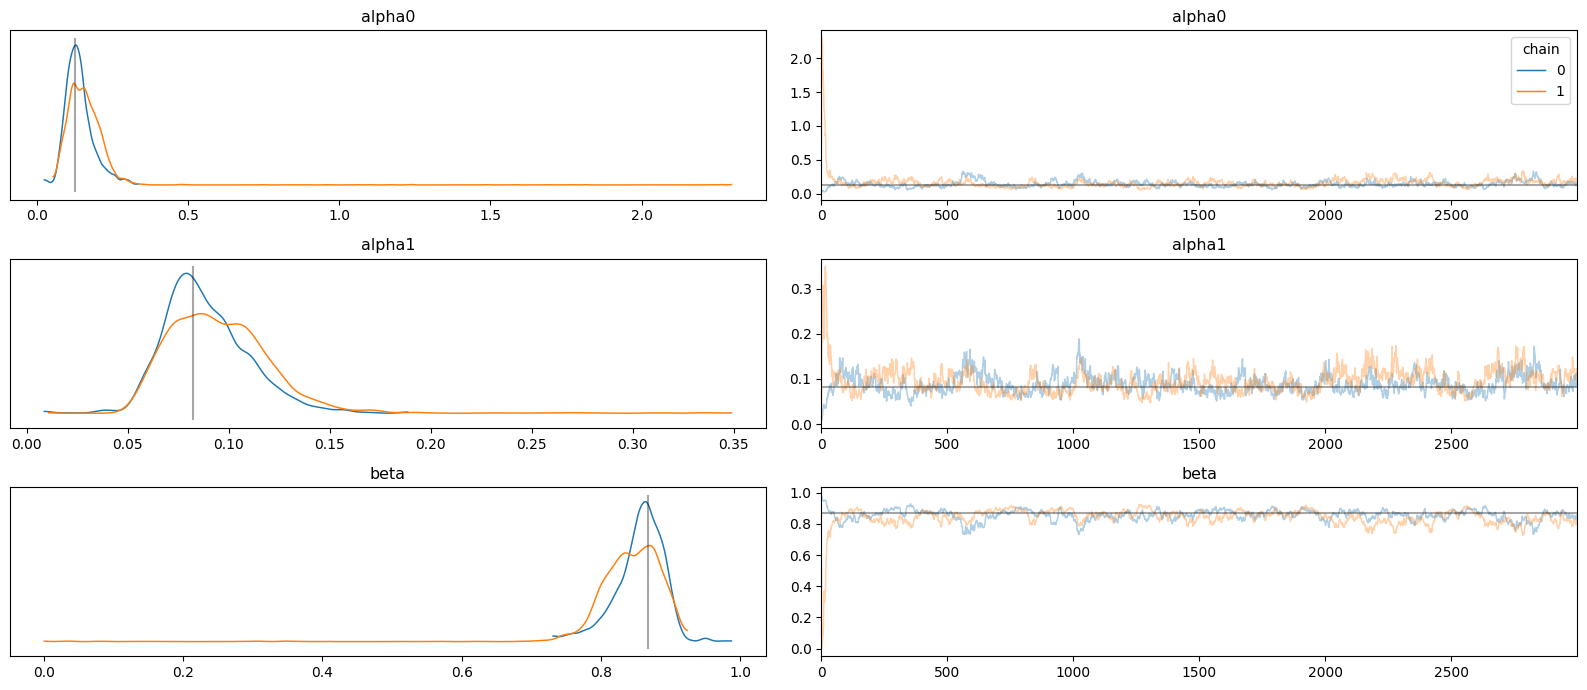

In [29]:
# Plot Second round MCMC model posteriors
with mcmc:
    step_mmc = pm.Slice()
    trace_mmc = pm.sample(
    3000,
    cores=2,
    step=step_mmc,
    tune=0, # no burn-in
    return_inferencedata=True,
    random_seed=12345,
    )
    az.plot_trace(
    trace_mmc,
    var_names=["alpha0", "alpha1", "beta"],
    lines=[
    ("alpha0", {}, [0.124993]),
    ("alpha1", {}, [0.082160]),
    ("beta", {}, [0.867127]),
    ],
    compact=False,
    legend=True,
    figsize=(16, 7),
    )
    plt.tight_layout()
    plt.show()

In [30]:
az.summary(trace_mmc, round_to=7).loc[["alpha0", "alpha1", "beta"], :]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha0,0.151440,0.091908,0.067844,0.240691,0.007156,0.043919,82.938764,221.227579,1.029334
alpha1,0.092149,0.024706,0.054129,0.132585,0.002455,0.002861,92.183544,318.266329,1.024602
beta,0.848298,0.051242,0.782080,0.913977,0.004892,0.015678,75.874103,231.988360,1.030617
